<a href="https://colab.research.google.com/github/carollinemelloo/ProcessamentoDeImagens/blob/main/AnaBeatrizECarolline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dupla: Ana Beatriz Nunes e Carolline Mello
# CC8MA

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
arquivo = files.upload()

Saving img_a.png to img_a.png
Saving img_b.png to img_b.png
Saving img_c.png to img_c.png


In [4]:
img_a = cv2.imread('img_a.png')
img_b = cv2.imread('img_b.png')
img_c = cv2.imread('img_c.png')

img_a_gray = cv2.cvtColor(img_a, cv2.COLOR_BGR2GRAY)
img_b_gray = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY)
img_c_gray = cv2.cvtColor(img_c, cv2.COLOR_BGR2GRAY)

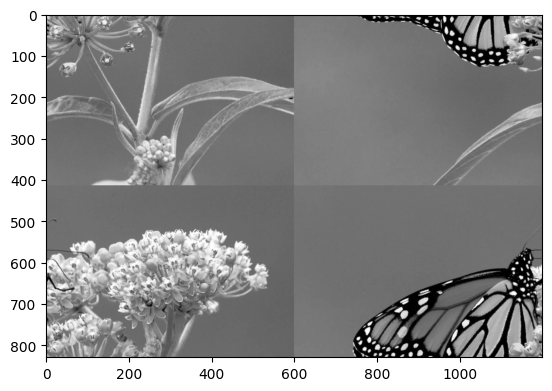

In [7]:
plt.imshow(img_a_gray, cmap='gray')

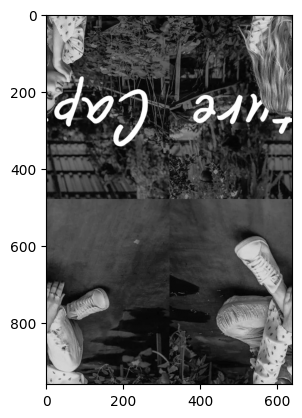

In [8]:
plt.imshow(img_b_gray, cmap='gray')

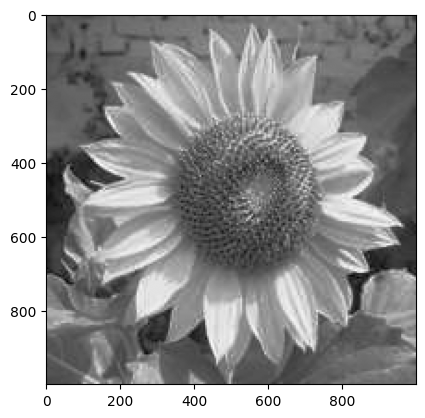

In [9]:
plt.imshow(img_c_gray, cmap='gray')

In [10]:
altura_a = img_a_gray.shape[0]
largura_a = img_a_gray.shape[1]

altura_b = img_b_gray.shape[0]
largura_b = img_b_gray.shape[1]

altura_c = img_c_gray.shape[0]
largura_c = img_c_gray.shape[1]

# Parte I - Construção dos Algoritmos

In [11]:
def translacao_exclusao(img, dx, dy):
    altura, largura = img.shape
    resultado = np.zeros((altura, largura), dtype=np.uint8)
    for x in range(largura):
        for y in range(altura):
            novo_x = x + dx
            novo_y = y + dy
            if 0 <= novo_x < largura and 0 <= novo_y < altura:
                resultado[novo_y, novo_x] = img[y, x]
    return resultado

In [12]:
def translacao_wrap_around(img, dx, dy):
    altura, largura = img.shape
    resultado = np.zeros((altura, largura), dtype=np.uint8)
    for x in range(largura):
        for y in range(altura):
            novo_x = (x + dx) % largura
            novo_y = (y + dy) % altura
            resultado[novo_y, novo_x] = img[y, x]
    return resultado

In [13]:
def escalamento(img, sx, sy):
    altura, largura = img.shape
    nova_largura = int(largura * sx)
    nova_altura = int(altura * sy)
    resultado = np.zeros((nova_altura, nova_largura), dtype=np.uint8)
    for x in range(nova_largura):
        for y in range(nova_altura):
            origem_x = int(x / sx)
            origem_y = int(y / sy)
            origem_x = min(origem_x, largura - 1)
            origem_y = min(origem_y, altura - 1)
            resultado[y, x] = img[origem_y, origem_x]
    return resultado


In [14]:
def espelhamento(img):
    altura, largura = img.shape
    resultado = np.zeros((altura, largura), dtype=np.uint8)
    for x in range(largura):
        for y in range(altura):
            novo_x = largura - 1 - x
            novo_y = altura - 1 - y
            resultado[novo_y, novo_x] = img[y, x]
    return resultado

# Parte II - Correção das Imagens

Correção da Imagem A

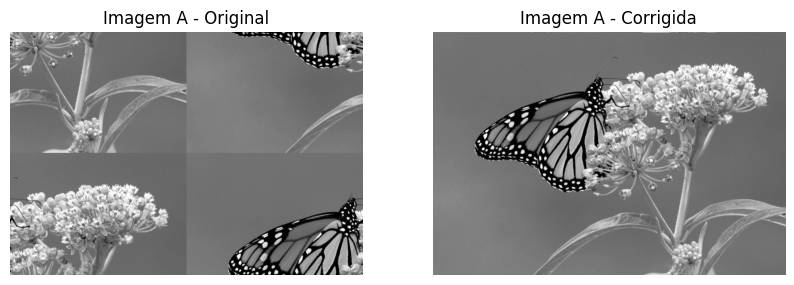

In [26]:
dx_a_inverso = 600
dy_a_inverso = 420

img_a_corrigida = translacao_wrap_around(img_a_gray, dx_a_inverso, dy_a_inverso)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_a_gray, cmap='gray')
axes[0].set_title('Imagem A - Original')
axes[0].axis('off')

axes[1].imshow(img_a_corrigida, cmap='gray')
axes[1].set_title('Imagem A - Corrigida')
axes[1].axis('off')

plt.show()

Justificativa: Na imagem A, foi utilizado os parâmetros dx = 600 e dy = 420, para que a imagem fosse realinhada nos seus eixos e consequentemente reorganizando a imagem.

Correção da Imagem B

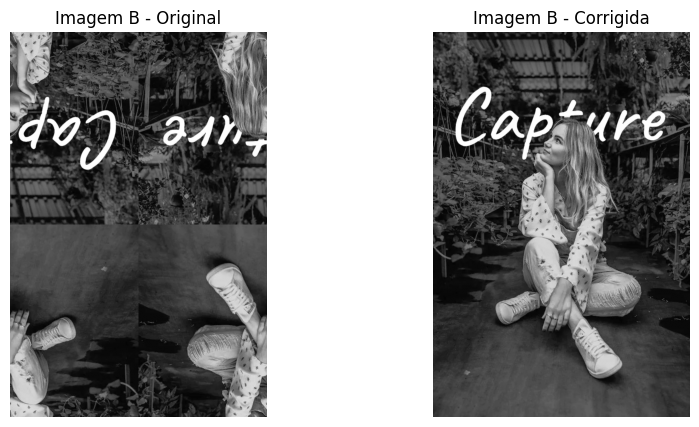

In [43]:
img_b_desespelhada = espelhamento(img_b_gray)

altura_b, largura_b = img_b_gray.shape

dx_b_inverso = 960
dy_b_inverso = altura_b // 2

img_b_corrigida = translacao_wrap_around(img_b_desespelhada, dx_b_inverso, dy_b_inverso)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_b_gray, cmap='gray')
axes[0].set_title('Imagem B - Original')
axes[0].axis('off')

axes[1].imshow(img_b_corrigida, cmap='gray')
axes[1].set_title('Imagem B - Corrigida')
axes[1].axis('off')

plt.show()

Na imagem B, foi primeiro feito a operação com o algoritmo de **espelhamento**, e após isso, foi feito a operação com o algoritmo de **translação wrap-around**. Justificativa: foi utilizado o parâmetro de dx = 960 e dy = altura//2 para que a imagem fosse primeiramente alinhada com sua devida metade e após, foi-se ajustando o parâmetro X para que a imagem ficasse centralizada e reorganizada.

Correção da Imagem C

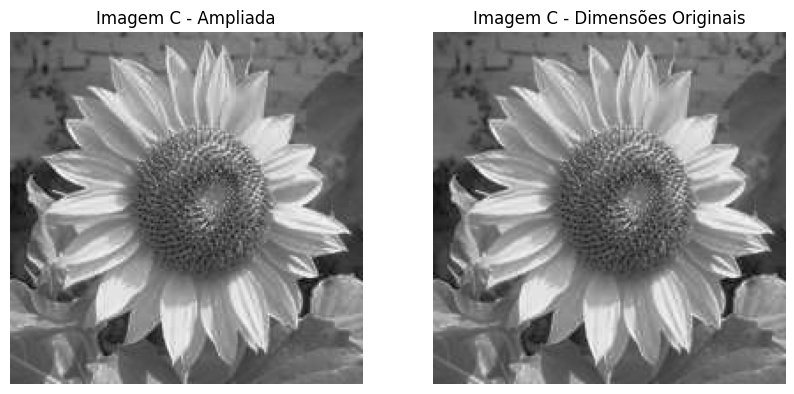

In [47]:
sx_c_inverso = 0.2
sy_c_inverso = 0.2

img_c_corrigida = escalamento(img_c_gray, sx_c_inverso, sy_c_inverso)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_c_gray, cmap='gray')
axes[0].set_title('Imagem C - Ampliada')
axes[0].axis('off')

axes[1].imshow(img_c_corrigida, cmap='gray')
plt.imsave('escalada.png', img_c_corrigida)
axes[1].set_title('Imagem C - Dimensões Originais')
axes[1].axis('off')
plt.show()


Justificativa: Na imagem C foi utilizado a multiplicação da altura e largura da imagem que foi recebida pelo parâmetro de 0.2 em ambas, o que fez com que ela voltasse ao seu tamanho original sendo ele 200x200.

# Parte III - Pipeline de Transformações

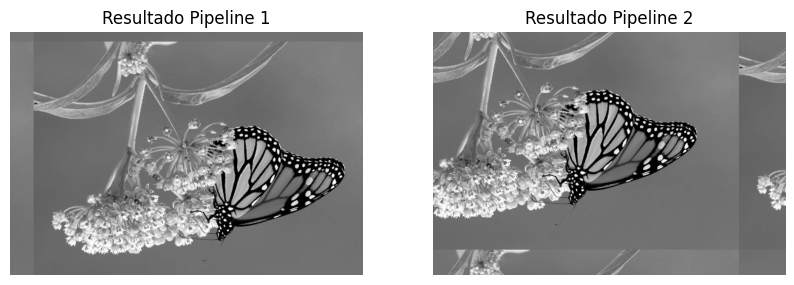

In [48]:
img_base = img_a_corrigida

pipe1_passo1 = espelhamento(img_base)
pipe1_passo2 = translacao_wrap_around(pipe1_passo1, 80, 40)
img_pipeline1 = escalamento(pipe1_passo2, 0.5, 0.5)

pipe2_passo1 = escalamento(img_base, 0.5, 0.5)
pipe2_passo2 = translacao_wrap_around(pipe2_passo1, 80, 40)
img_pipeline2 = espelhamento(pipe2_passo2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_pipeline1, cmap='gray')
axes[0].set_title('Resultado Pipeline 1')
axes[0].axis('off')

axes[1].imshow(img_pipeline2, cmap='gray')
axes[1].set_title('Resultado Pipeline 2')
axes[1].axis('off')
plt.show()

# Justificativa e Análise dos Pipes

1. As imagens não ficaram iguais. Os resultados visuais e o mapeamento dos pixels são notavelmente diferentes.

2. A ordem das operações afeta diretamente no resultado, já que as transformações geométricas não são necessariamente comutativas. Como exemplo, a translação feita antes do escalamento desloca a imagem em sua dimensão original, na pipe 1. Já na pipe 2, a translação foi feita posteriormente ao escalamento, ou seja, feita em uma imagem que já teve sua largura reduzida pela metade, o que resultou em um deslocamento mais perceptível. Além disso, espelhar a imagem antes ou depois da translação wrap-around inverte a direção aparente do conteúdo que atravessa as bordas.

3. As dimensões são alteradas na etapa de escalamento. No pipe 1, o escalamento é a última etapa. Logo, o espelhamento e o wrap-around acontecem sob os limites de largura e altura originais. Já no pipe 2, o escalamento é a primeira etapa, ou seja, muda os limites matemáticos da altura e largura. Como as funções de wrap around e de espelhamento dependem destas propriedades de shape da matriz de entrada, suas lógicas matemáticas interagem com uma grade de pixels menos, consequentemente distorcendo o comportamento da imagem em relação ao pipe 1.